<a href="https://colab.research.google.com/github/malakkorashy/my-app/blob/main/Copy_of_Graduation_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install shap xgboost imbalanced-learn -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, f1_score)
from imblearn.over_sampling import SMOTE
import shap
import warnings
warnings.filterwarnings('ignore')

In [ ]:


df = pd.read_csv('/content/ncr_ride_bookings.csv')
print(df.shape)
df.head()


(150000, 21)


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [ ]:
df.info()
print("\n--- Booking Status distribution ---")
print(df['Booking Status'].value_counts())
print("\n--- Missing values ---")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

In [ ]:
df['Target'] = df['Booking Status'].apply(lambda x: 1 if x == 'Completed' else 0)

print(df['Target'].value_counts())
print(df['Target'].value_counts(normalize=True))

Target
1    93000
0    57000
Name: count, dtype: int64
Target
1    0.62
0    0.38
Name: proportion, dtype: float64


In [ ]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S', errors='coerce')

df['Hour'] = df['Time'].dt.hour
df['DayOfWeek'] = df['Date'].dt.dayofweek       # 0 = Monday
df['Month'] = df['Date'].dt.month
df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

In [ ]:
#

features = ['Vehicle Type', 'Pickup Location', 'Drop Location',
            'Payment Method', 'Hour', 'DayOfWeek', 'Month',
            'IsWeekend', 'Avg VTAT']


data = df[features + ['Target']].copy()
data.head()

,Vehicle Type,Pickup Location,Drop Location,Payment Method,Hour,DayOfWeek,Month,IsWeekend,Avg VTAT,Target
0,eBike,Palam Vihar,Jhilmil,NaN,12,5,3,1,NaN,0
1,Go Sedan,Shastri Nagar,Gurgaon Sector 56,UPI,18,4,11,0,4.9,0
2,Auto,Khandsa,Malviya Nagar,Debit Card,8,4,8,0,13.4,1
3,Premier Sedan,Central Secretariat,Inderlok,UPI,17,0,10,0,13.1,1
4,Bike,Ghitorni Village,Khan Market,UPI,22,0,9,0,5.3,1


In [ ]:
# Numerical Columns
data['Avg VTAT'] = data['Avg VTAT'].fillna(data['Avg VTAT'].median())

# Categorical Columns
cat_cols = ['Vehicle Type', 'Pickup Location', 'Drop Location', 'Payment Method']
for col in cat_cols:
    data[col] = data[col].fillna('Unknown')

In [ ]:
# Keep the top 20 locations and group the rest as "Other"
top_pickup = data['Pickup Location'].value_counts().nlargest(20).index
top_drop = data['Drop Location'].value_counts().nlargest(20).index

data['Pickup Location'] = data['Pickup Location'].apply(lambda x: x if x in top_pickup else 'Other')
data['Drop Location'] = data['Drop Location'].apply(lambda x: x if x in top_drop else 'Other')

In [ ]:
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    encoders[col] = le

In [ ]:
X = data.drop('Target', axis=1)
y = data['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(120000, 9) (30000, 9)


In [ ]:
print("Before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(y_train.value_counts())

Before SMOTE:
Target
1    74400
0    45600
Name: count, dtype: int64

After SMOTE:
Target
1    74400
0    74400
Name: count, dtype: int64


In [ ]:
log_model = LogisticRegression(class_weight='balanced', max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, log_model.predict_proba(X_test)[:, 1]))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.82      0.86      0.84     11400
           1       0.91      0.88      0.90     18600

    accuracy                           0.87     30000
   macro avg       0.86      0.87      0.87     30000
weighted avg       0.87      0.87      0.87     30000

ROC-AUC: 0.9265332673080551


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=10, class_weight='balanced', random_state=42
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1]))

=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      0.84      0.91     11400
           1       0.91      1.00      0.95     18600

    accuracy                           0.94     30000
   macro avg       0.95      0.92      0.93     30000
weighted avg       0.94      0.94      0.94     30000

ROC-AUC: 0.9500777541973212


In [ ]:

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=42
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1]))

=== XGBoost ===
              precision    recall  f1-score   support

           0       1.00      0.84      0.91     11400
           1       0.91      1.00      0.95     18600

    accuracy                           0.94     30000
   macro avg       0.95      0.92      0.93     30000
weighted avg       0.94      0.94      0.94     30000

ROC-AUC: 0.9488970005659308


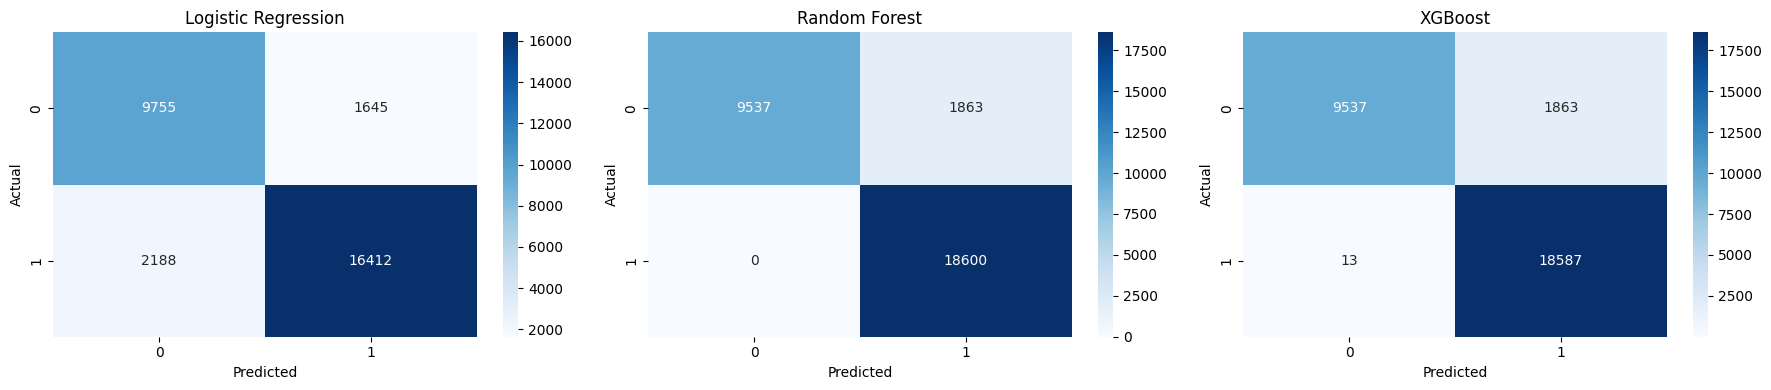

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
models = {'Logistic Regression': y_pred_log, 'Random Forest': y_pred_rf, 'XGBoost': y_pred_xgb}

for ax, (name, preds) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

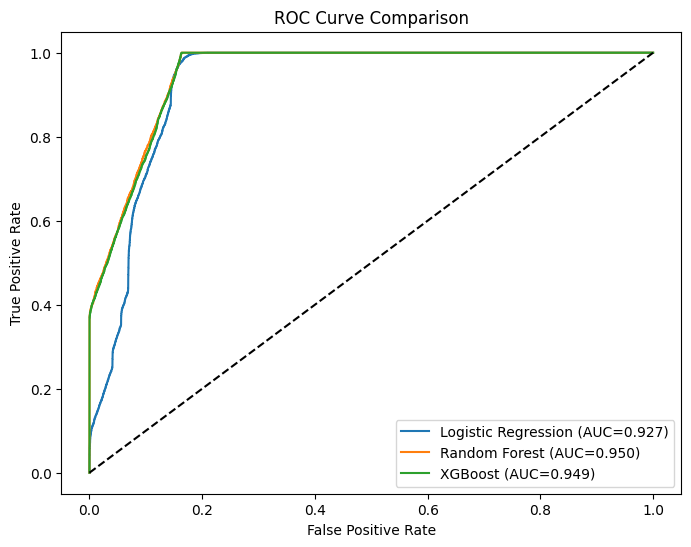

In [ ]:
plt.figure(figsize=(8, 6))
for name, model in [('Logistic Regression', log_model), ('Random Forest', rf_model), ('XGBoost', xgb_model)]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

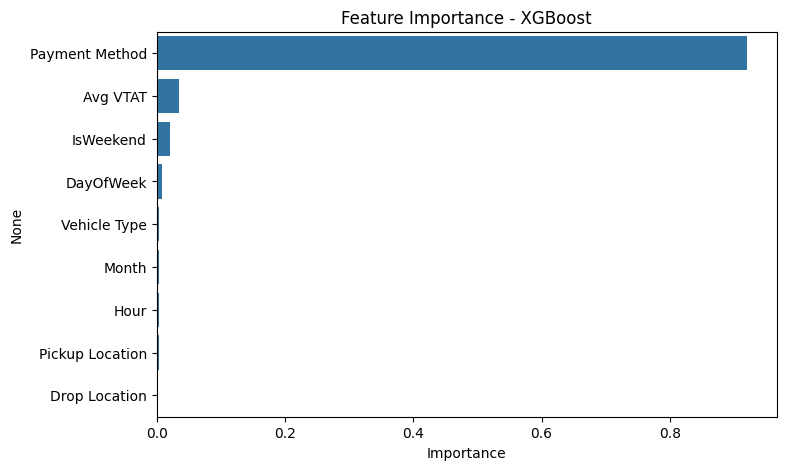

In [ ]:
importances = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index)
plt.title('Feature Importance - XGBoost')
plt.xlabel('Importance')
plt.show()

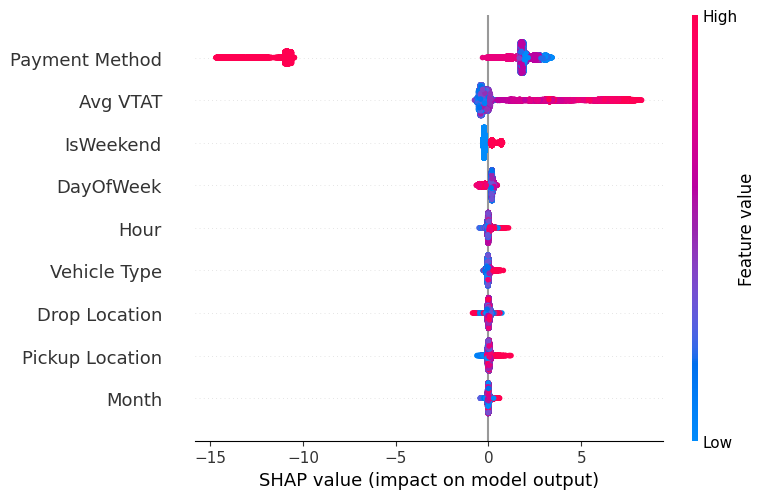

In [ ]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Summary Plot - Shows how each feature affects the model's prediction
shap.summary_plot(shap_values, X_test, feature_names=X.columns)

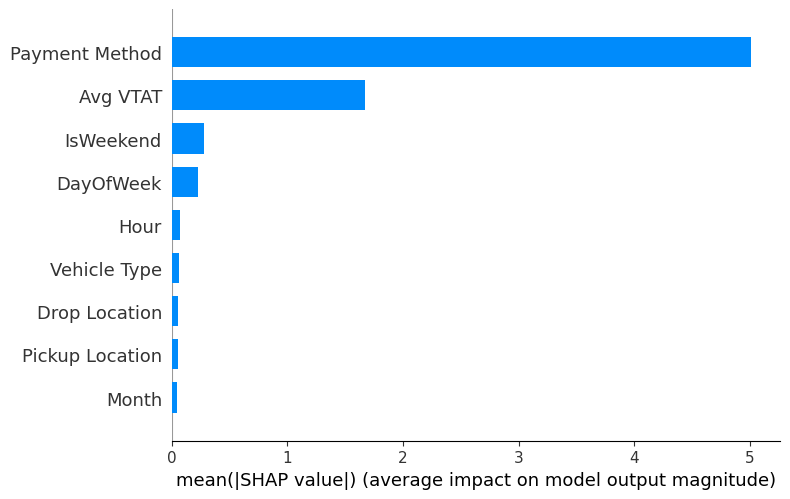

In [ ]:
shap.summary_plot(shap_values, X_test, feature_names=X.columns, plot_type='bar')

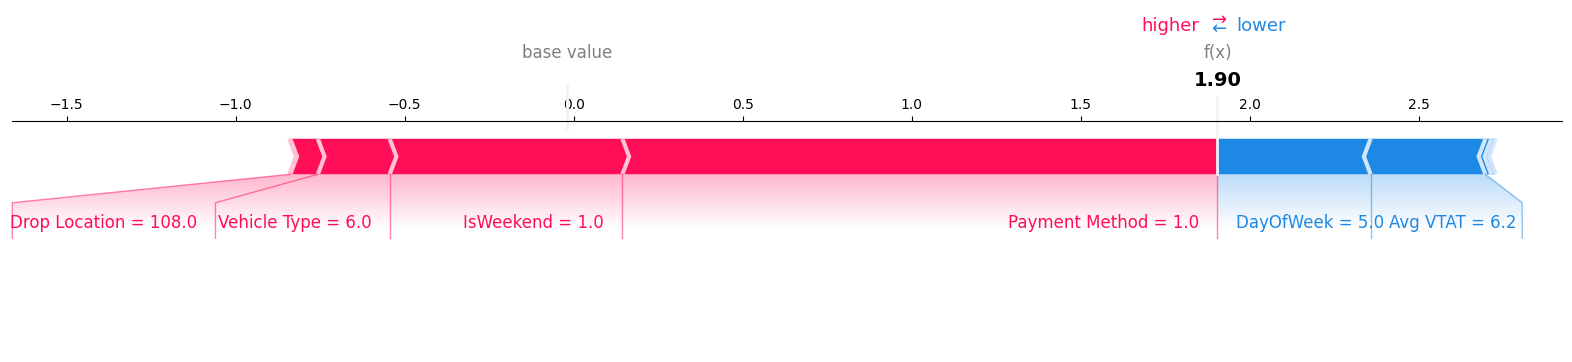

In [ ]:
# Select a test sample to explain (change the index to analyze a different ride)
idx = 0

shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_test.iloc[idx],
    matplotlib=True
)

In [ ]:
import joblib
joblib.dump(xgb_model, 'ride_completion_model.pkl')
joblib.dump(encoders, 'label_encoders.pkl')

from google.colab import files
files.download('ride_completion_model.pkl')
files.download('label_encoders.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
sample = X_test.sample(20, random_state=5)
preds = xgb_model.predict(sample)
probs = xgb_model.predict_proba(sample)[:, 1]

for i in range(20):
    print(f"Prediction: {preds[i]} | Probability: {round(probs[i]*100,2)}%")


Prediction: 0 | Probability: 0.0%
Prediction: 1 | Probability: 65.16999816894531%
Prediction: 0 | Probability: 0.0%
Prediction: 1 | Probability: 99.98999786376953%
Prediction: 0 | Probability: 0.0%
Prediction: 1 | Probability: 78.6500015258789%
Prediction: 0 | Probability: 0.0%
Prediction: 1 | Probability: 97.38999938964844%
Prediction: 1 | Probability: 100.0%
Prediction: 1 | Probability: 77.9000015258789%
Prediction: 1 | Probability: 85.2699966430664%
Prediction: 1 | Probability: 85.58000183105469%
Prediction: 1 | Probability: 82.56999969482422%
Prediction: 1 | Probability: 82.6500015258789%
Prediction: 0 | Probability: 0.0%
Prediction: 0 | Probability: 0.0%
Prediction: 1 | Probability: 85.4000015258789%
Prediction: 0 | Probability: 0.0%
Prediction: 1 | Probability: 84.5199966430664%
Prediction: 0 | Probability: 0.0%


In [ ]:
print(df['Booking Status'].value_counts())

Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64


In [ ]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      0.84      0.91     11400
           1       0.91      1.00      0.95     18600

    accuracy                           0.94     30000
   macro avg       0.95      0.92      0.93     30000
weighted avg       0.94      0.94      0.94     30000



In [ ]:
def predict_ride_status():
    print("Ride Completion Prediction\n")

    date_str = input("Enter Date (YYYY-MM-DD): ")
    date_obj = pd.to_datetime(date_str)

    time_str = input("Enter Time (HH:MM): ")
    hour = int(time_str.split(':')[0])

    print("\nAvailable Vehicle Types:", list(encoders['Vehicle Type'].classes_))
    vehicle = input("Enter Vehicle Type: ")

    print("\nAvailable Pickup Locations:", list(encoders['Pickup Location'].classes_))
    pickup = input("Enter Pickup Location: ")

    print("\nAvailable Drop Locations:", list(encoders['Drop Location'].classes_))
    drop = input("Enter Drop Location: ")

    print("\nAvailable Payment Methods:", list(encoders['Payment Method'].classes_))
    payment = input("Enter Payment Method: ")

    vtat = float(input("\nEnter Average Vehicle Arrival Time (Avg VTAT): "))

    day_of_week = date_obj.dayofweek
    month = date_obj.month
    is_weekend = 1 if day_of_week >= 5 else 0

    new_ride = pd.DataFrame({
        'Vehicle Type': [vehicle],
        'Pickup Location': [pickup],
        'Drop Location': [drop],
        'Payment Method': [payment],
        'Hour': [hour],
        'DayOfWeek': [day_of_week],
        'Month': [month],
        'IsWeekend': [is_weekend],
        'Avg VTAT': [vtat]
    })

    for col in cat_cols:
        val = new_ride[col].iloc[0]
        if val in encoders[col].classes_:
            new_ride[col] = encoders[col].transform([val])
        else:
            fallback = 'Other' if 'Other' in encoders[col].classes_ else encoders[col].classes_[0]
            print(f"Warning: '{val}' is not available in the training data. Using '{fallback}' instead.")
            new_ride[col] = encoders[col].transform([fallback])

    prediction = xgb_model.predict(new_ride)[0]
    probability = xgb_model.predict_proba(new_ride)[0][1]

    print("\nPrediction Result")
    print("-" * 30)

    if prediction == 1:
        print("Predicted Status: Completed")
    else:
        print("Predicted Status: Not Completed")

    print(f"Completion Probability: {probability:.2%}")


predict_ride_status()

Ride Completion Prediction

Enter Date (YYYY-MM-DD): 24-05-2024
Enter Time (HH:MM): 09:07

Available Vehicle Types: ['Auto', 'Bike', 'Go Mini', 'Go Sedan', 'Premier Sedan', 'Uber XL', 'eBike']
Enter Vehicle Type: eBike

Available Pickup Locations: ['AIIMS', 'Adarsh Nagar', 'Akshardham', 'Ambience Mall', 'Anand Vihar', 'Anand Vihar ISBT', 'Ardee City', 'Arjangarh', 'Ashok Park Main', 'Ashok Vihar', 'Ashram', 'Aya Nagar', 'Azadpur', 'Badarpur', 'Badshahpur', 'Bahadurgarh', 'Barakhamba Road', 'Basai Dhankot', 'Bhikaji Cama Place', 'Bhiwadi', 'Botanical Garden', 'Central Secretariat', 'Chanakyapuri', 'Chandni Chowk', 'Chhatarpur', 'Chirag Delhi', 'Civil Lines Gurgaon', 'Connaught Place', 'Cyber Hub', 'DLF City Court', 'DLF Phase 3', 'Delhi Gate', 'Dilshad Garden', 'Dwarka Mor', 'Dwarka Sector 21', 'Faridabad Sector 15', 'GTB Nagar', 'Ghaziabad', 'Ghitorni', 'Ghitorni Village', 'Golf Course Road', 'Govindpuri', 'Greater Kailash', 'Greater Noida', 'Green Park', 'Gurgaon Railway Station', 'Gu